# SHAP and PDP explainability

In [1]:
pip install shap

  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ----- ---------------------------------- 5.2/41.9 MB 24.3 MB/s eta 0:00:02
   ---------- ----------------------------- 11.3/41.9 MB 26.2 MB/s eta 0:00:02
   ---------------- ----------------------- 17.3/41.9 MB 26.7 MB/s eta 0:00:01
   ---------------------- ----------------- 23.1/41.9 MB 26.9 MB/s eta 0:00:01
   --------------------------- ------------ 28.6/41.9 MB 27.0 MB/s eta 0:00:01
   -------------------------------- ------- 34.3/41.9 MB 26.6 MB/s eta 0:00:01
   -------------------------------------- - 40.1/41.9 MB 26.8 MB/s eta 0:00:01
   ---------------------------------------- 41.9/41.9 MB 25.4 MB/s  0:00:01
   ---------------------------------------- 0.0/2.8 MB ? eta -:-

In [8]:
# libraries and packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib

from pathlib import Path
from scipy import sparse
from sklearn.inspection import (PartialDependenceDisplay)

In [6]:
# Setting up the paths
project_root = (
    Path.cwd().parent
    if Path.cwd().name == 'notebooks'
    else Path.cwd()
)

features_path = (
    project_root
    / 'data'
    / 'processed'
    / 'ca1_model_features.parquet'
)

model_path = (
    project_root
    / 'models'
    / 'final_random_forest_tuned_pipeline.joblib'
)

reports_directory = (
    project_root
    / 'reports'
)

figures_directory = (
    reports_directory
    / 'figures'
)

reports_directory.mkdir(
    parents=True,
    exist_ok=True
)

figures_directory.mkdir(
    parents=True,
    exist_ok=True
)

In [9]:
# Loading the data from the previous process
feature_df = pd.read_parquet(
    features_path
)

feature_df['date'] = pd.to_datetime(
    feature_df['date']
)

final_rf_pipeline = joblib.load(
    model_path
)

print(
    final_rf_pipeline.named_steps.keys()
)

print(
    f'Feature rows: '
    f'{len(feature_df):,}'
)

dict_keys(['preprocessor', 'regressor'])
Feature rows: 166,886


In [10]:
# defining the predictors
numeric_features = [
    'lag_1',
    'lag_7',
    'lag_14',
    'lag_28',
    'rolling_mean_7',
    'rolling_mean_28',
    'rolling_std_7',
    'sell_price',
    'price_change',
    'event_indicator'
]

categorical_features = [
    'weekday',
    'month',
    'item_id',
    'dept_id',
    'cat_id'
]

model_features = (
    numeric_features
    + categorical_features
)

target = 'sales'

In [11]:
# Extracting the feature importances from the models
preprocessor = (
    final_rf_pipeline.named_steps[
        'preprocessor'
    ]
)

random_forest = (
    final_rf_pipeline.named_steps[
        'regressor'
    ]
)

transformed_feature_names = (
    preprocessor
    .get_feature_names_out()
)

feature_importance = pd.DataFrame({
    'transformed_feature':
        transformed_feature_names,
    'importance':
        random_forest.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        'importance',
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    f'Transformed features: '
    f'{len(feature_importance):,}'
)

print(
    f'Total importance: '
    f'{feature_importance["importance"].sum():.4f}'
)

feature_importance.head(20)

Transformed features: 147
Total importance: 1.0000


,transformed_feature,importance
0,numeric__rolling_mean_7,0.201291
1,numeric__rolling_mean_28,0.175837
2,numeric__rolling_std_7,0.101139
3,numeric__lag_7,0.097442
4,numeric__lag_1,0.095879
5,numeric__lag_14,0.080567
6,numeric__lag_28,0.058732
7,categorical__item_id_FOODS_3_499,0.033285
8,numeric__sell_price,0.024293
9,categorical__dept_id_FOODS_3,0.010005


In [12]:
# Averaging the OHE encoded importance 
def identify_original_feature(
    transformed_feature
):
    clean_name = (
        transformed_feature
        .split('__', maxsplit=1)[-1]
    )

    for feature in categorical_features:
        if (
            clean_name == feature
            or clean_name.startswith(
                f'{feature}_'
            )
        ):
            return feature

    for feature in numeric_features:
        if clean_name == feature:
            return feature

    return clean_name

Categorical variables were one-hot encoded. Their SHAP values and model importance were therefore distributed across multiple encoded columns and were aggregated back to their original predictor groups.


In [13]:
feature_importance[
    'original_feature'
] = (
    feature_importance[
        'transformed_feature'
    ].apply(
        identify_original_feature
    )
)

grouped_model_importance = (
    feature_importance
    .groupby(
        'original_feature',
        as_index=False
    )['importance']
    .sum()
    .sort_values(
        'importance',
        ascending=False
    )
    .reset_index(drop=True)
)

grouped_model_importance

,original_feature,importance
0,rolling_mean_7,0.201291
1,rolling_mean_28,0.175837
2,rolling_std_7,0.101139
3,lag_7,0.097442
4,lag_1,0.095879
5,item_id,0.084540
6,lag_14,0.080567
7,lag_28,0.058732
8,weekday,0.026970
9,sell_price,0.024293


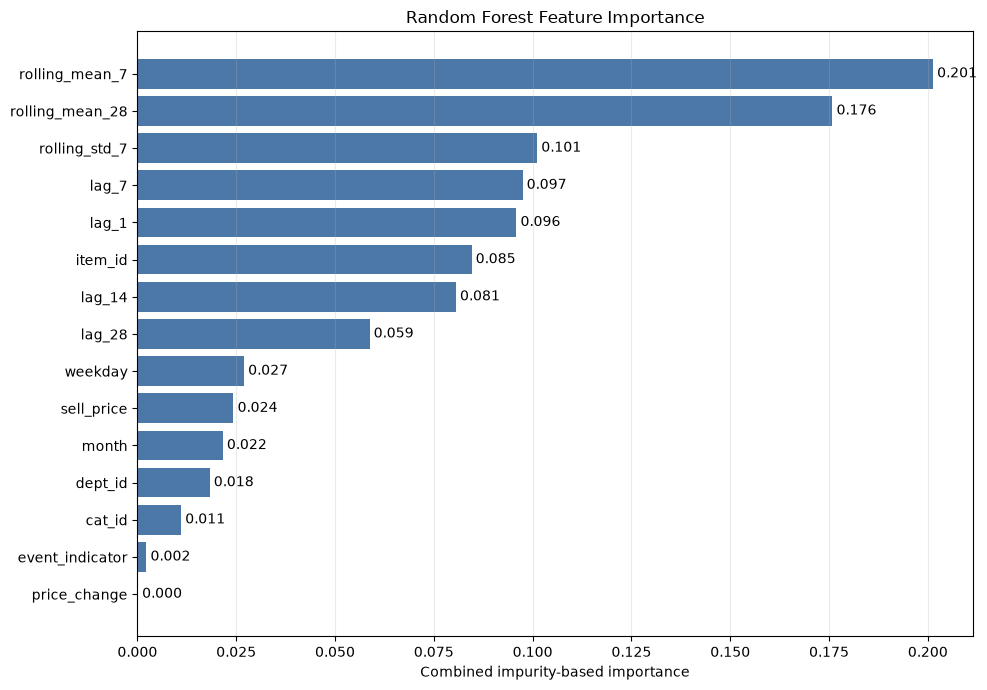

In [14]:
# Plot
plot_data = (
    grouped_model_importance
    .sort_values('importance')
)

fig, ax = plt.subplots(
    figsize=(10, 7)
)

bars = ax.barh(
    plot_data[
        'original_feature'
    ],
    plot_data[
        'importance'
    ],
    color='#4C78A8'
)

ax.bar_label(
    bars,
    fmt='%.3f',
    padding=3
)

ax.set_title(
    'Random Forest Feature Importance'
)

ax.set_xlabel(
    'Combined impurity-based importance'
)

ax.set_ylabel('')

ax.grid(
    axis='x',
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    figures_directory
    / 'random_forest_feature_importance.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### SHAP

In [15]:
# Selecting the managable samples for SHAP
development_df = feature_df.loc[
    feature_df['date']
    <= pd.Timestamp(
        '2016-04-24'
    )
].copy()

shap_sample = (
    development_df
    .sample(
        n=min(
            300,
            len(development_df)
        ),
        random_state=10
    )
)

X_shap = shap_sample[
    model_features
]

print(
    f'SHAP observations: '
    f'{len(X_shap):,}'
)

SHAP observations: 300


300 rows should be computationally accessible

In [16]:
# Transforming the data
X_shap_transformed = (
    preprocessor.transform(
        X_shap
    )
)

if sparse.issparse(
    X_shap_transformed
):
    X_shap_transformed = (
        X_shap_transformed.toarray()
    )

print(
    f'Transformed SHAP shape: '
    f'{X_shap_transformed.shape}'
)

Transformed SHAP shape: (300, 147)


In [17]:
# Calculating the SHAP values
shap_explainer = shap.TreeExplainer(
    random_forest
)

shap_values = (
    shap_explainer.shap_values(
        X_shap_transformed,
        check_additivity=False
    )
)

if isinstance(
    shap_values,
    list
):
    shap_values = shap_values[0]

shap_values = np.asarray(
    shap_values
)

print(
    f'SHAP values shape: '
    f'{shap_values.shape}'
)

SHAP values shape: (300, 147)


SHAP values describe how predictors contributed to Random Forest predictions relative to the model's expected prediction. They explain model behaviour rather than causal effects on customer demand.


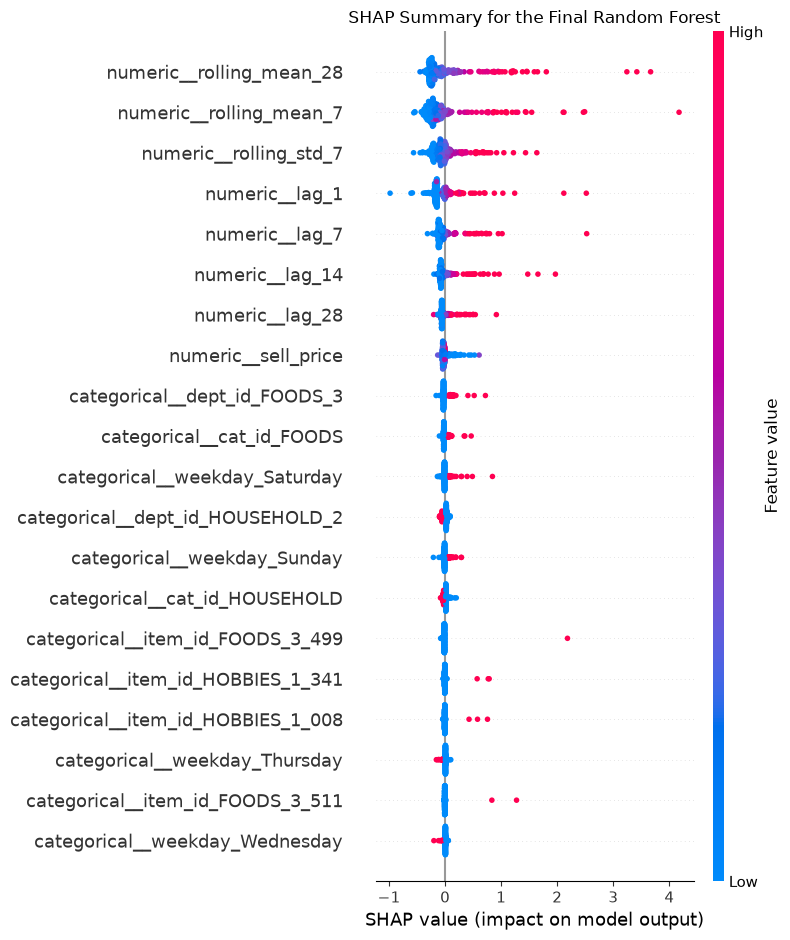

In [18]:
# Global SHAP summary plot
shap.summary_plot(
    shap_values,
    X_shap_transformed,
    feature_names=
        transformed_feature_names,
    max_display=20,
    show=False
)

plt.title(
    'SHAP Summary for the Final Random Forest'
)

plt.tight_layout()

plt.savefig(
    figures_directory
    / 'random_forest_shap_summary.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [19]:
# Aggregating SHAP importance features
mean_absolute_shap = (
    np.abs(shap_values)
    .mean(axis=0)
)

shap_importance = pd.DataFrame({
    'transformed_feature':
        transformed_feature_names,
    'mean_absolute_shap':
        mean_absolute_shap
})

shap_importance[
    'original_feature'
] = (
    shap_importance[
        'transformed_feature'
    ].apply(
        identify_original_feature
    )
)

grouped_shap_importance = (
    shap_importance
    .groupby(
        'original_feature',
        as_index=False
    )['mean_absolute_shap']
    .sum()
    .sort_values(
        'mean_absolute_shap',
        ascending=False
    )
    .reset_index(drop=True)
)

grouped_shap_importance

,original_feature,mean_absolute_shap
0,rolling_mean_28,0.309974
1,rolling_mean_7,0.298395
2,item_id,0.171398
3,rolling_std_7,0.170978
4,lag_1,0.166306
5,lag_7,0.128201
6,lag_14,0.115299
7,dept_id,0.107282
8,weekday,0.107062
9,lag_28,0.074226


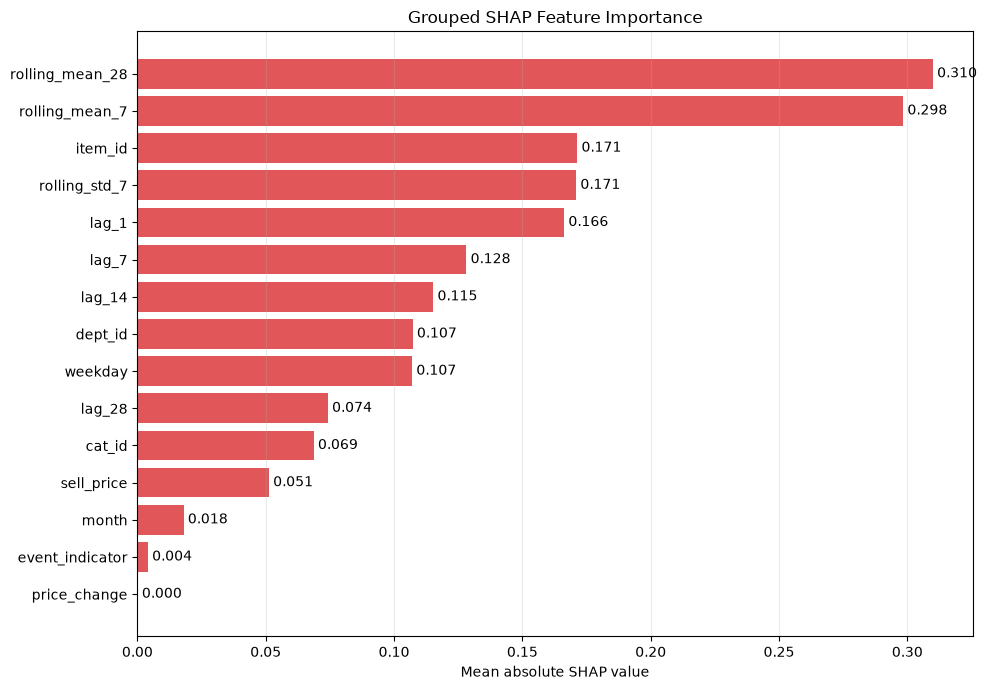

In [20]:
# PLOT
shap_plot_data = (
    grouped_shap_importance
    .sort_values(
        'mean_absolute_shap'
    )
)

fig, ax = plt.subplots(
    figsize=(10, 7)
)

bars = ax.barh(
    shap_plot_data[
        'original_feature'
    ],
    shap_plot_data[
        'mean_absolute_shap'
    ],
    color='#E15759'
)

ax.bar_label(
    bars,
    fmt='%.3f',
    padding=3
)

ax.set_title(
    'Grouped SHAP Feature Importance'
)

ax.set_xlabel(
    'Mean absolute SHAP value'
)

ax.set_ylabel('')

ax.grid(
    axis='x',
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    figures_directory
    / 'random_forest_grouped_shap.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [21]:
# Individual explanations
shap_metadata = (
    shap_sample[
        [
            'item_id',
            'date',
            'sales'
        ]
    ]
    .reset_index(drop=True)
)

positive_positions = np.flatnonzero(
    shap_metadata[
        'sales'
    ].to_numpy()
    > 0
)

positive_sales = (
    shap_metadata.loc[
        positive_positions,
        'sales'
    ]
)

median_positive_sales = (
    positive_sales.median()
)

typical_position = (
    positive_sales
    .sub(
        median_positive_sales
    )
    .abs()
    .idxmin()
)

shap_metadata.loc[
    typical_position
]

item_id            FOODS_3_698
date       2015-07-24 00:00:00
sales                        2
Name: 0, dtype: object

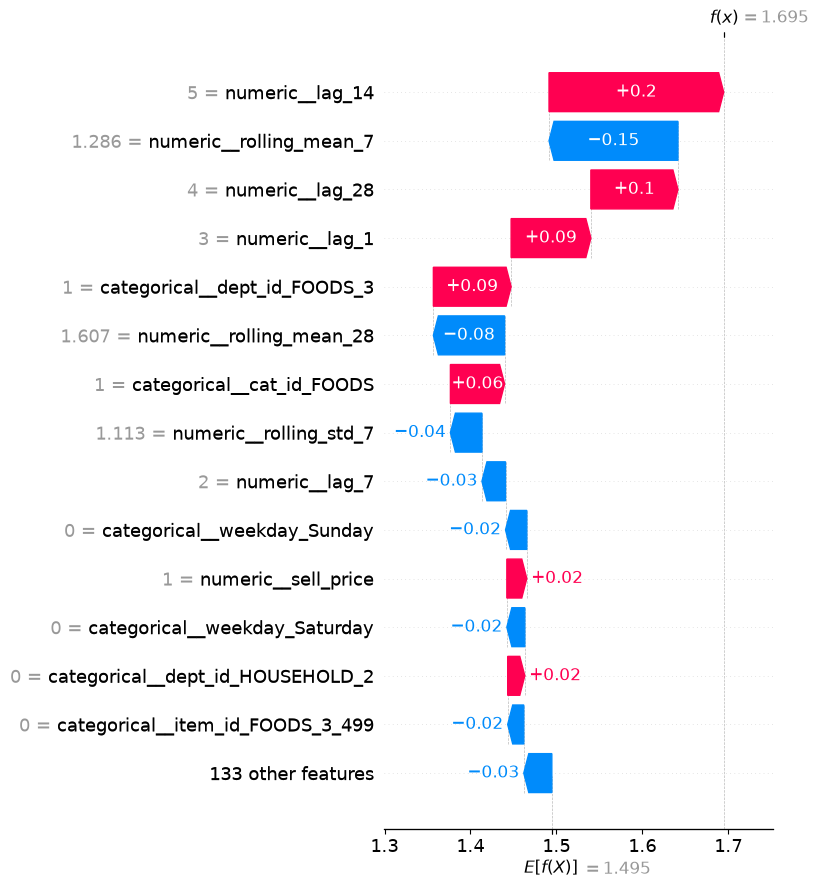

In [22]:
base_value = float(
    np.asarray(
        shap_explainer.expected_value
    ).reshape(-1)[0]
)

individual_explanation = shap.Explanation(
    values=shap_values[
        typical_position
    ],
    base_values=base_value,
    data=X_shap_transformed[
        typical_position
    ],
    feature_names=
        transformed_feature_names
)

shap.plots.waterfall(
    individual_explanation,
    max_display=15,
    show=False
)

plt.tight_layout()

plt.savefig(
    figures_directory
    / 'random_forest_shap_individual.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [24]:
# Predicting values
individual_row = X_shap.iloc[
    [typical_position]
]

individual_prediction = (
    final_rf_pipeline.predict(
        individual_row
    )[0]
)

individual_actual = (
    shap_metadata.loc[
        typical_position,
        'sales'
    ]
)

print(
    f'Actual sales: '
    f'{individual_actual:.2f}'
)

print(
    f'Predicted sales: '
    f'{individual_prediction:.2f}'
)

Actual sales: 2.00
Predicted sales: 1.69


Lag and rolling-demand variables are correlated because they are derived from related historical observations. Their individual importance should therefore be interpreted cautiously.


### Partial Dependence Plots (PDP)

In [26]:
# meaningful numeric feats
pdp_features = [
    'rolling_mean_7',
    'rolling_mean_28',
    'lag_7',
    'sell_price'
]

In [28]:
# Sampling to the managable size
X_pdp = (
    development_df[
        model_features
    ]
    .sample(
        n=min(
            3000,
            len(development_df)
        ),
        random_state=10
    )
)

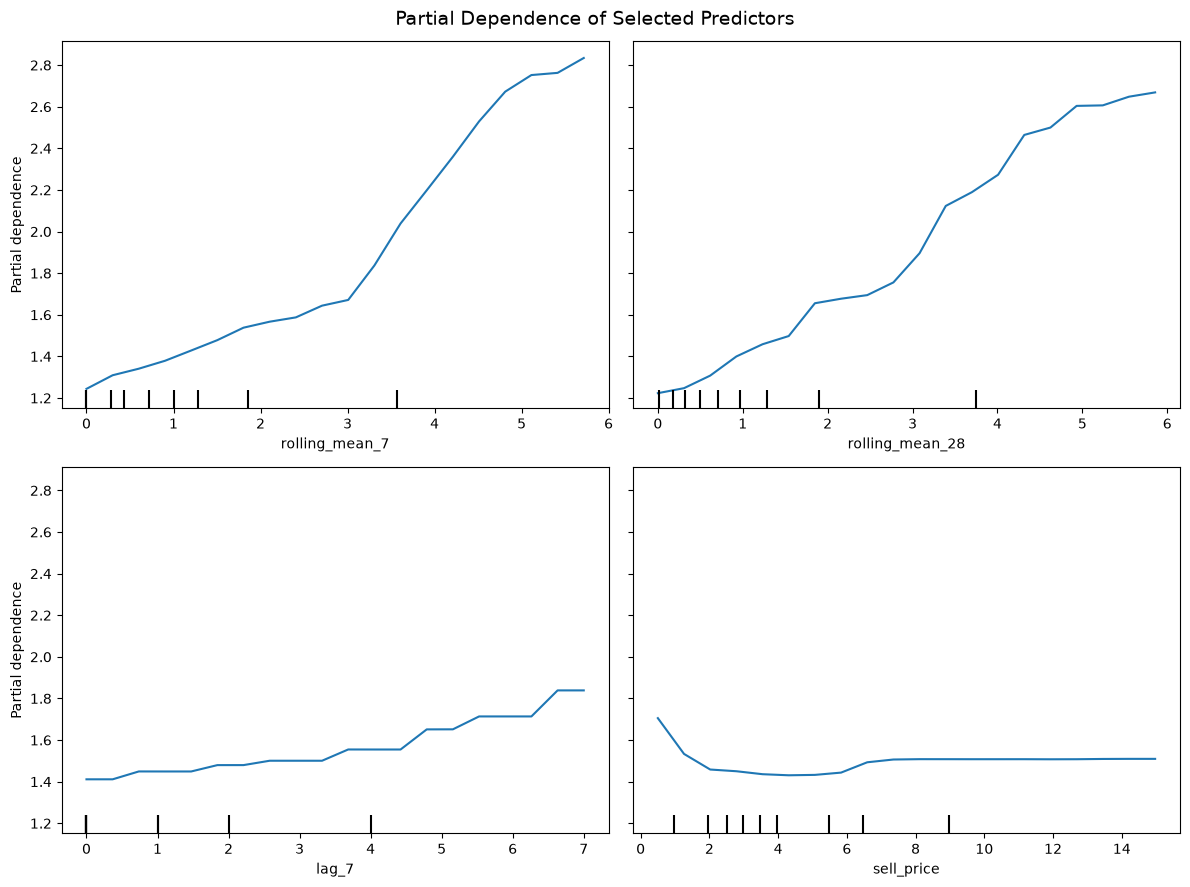

In [29]:
# PLOT
fig, ax = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(12, 9)
)

PartialDependenceDisplay.from_estimator(
    estimator=final_rf_pipeline,
    X=X_pdp,
    features=pdp_features,
    kind='average',
    grid_resolution=20,
    ax=ax
)

fig.suptitle(
    'Partial Dependence of Selected Predictors',
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    figures_directory
    / 'random_forest_partial_dependence.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [30]:
# Saving the result data
feature_importance.to_csv(
    reports_directory
    / 'random_forest_transformed_importance.csv',
    index=False
)

grouped_model_importance.to_csv(
    reports_directory
    / 'random_forest_grouped_importance.csv',
    index=False
)

shap_importance.to_csv(
    reports_directory
    / 'random_forest_transformed_shap.csv',
    index=False
)

grouped_shap_importance.to_csv(
    reports_directory
    / 'random_forest_grouped_shap.csv',
    index=False
)

shap_metadata.to_csv(
    reports_directory
    / 'shap_sample_metadata.csv',
    index=False
)

print('SHAP and PDP explainability results saved.')

SHAP and PDP explainability results saved.
